In [1]:
import pandas as pd
import joblib
import shap

X_train = pd.read_csv('../data/processed/X_train_fe.csv')
X_test = pd.read_csv('../data/processed/X_test_fe.csv')

final_model = joblib.load('../models/final_model_xgboost.pkl')

print("Model loaded:", type(final_model))

Model loaded: <class 'xgboost.sklearn.XGBClassifier'>


In [2]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1409, 35)


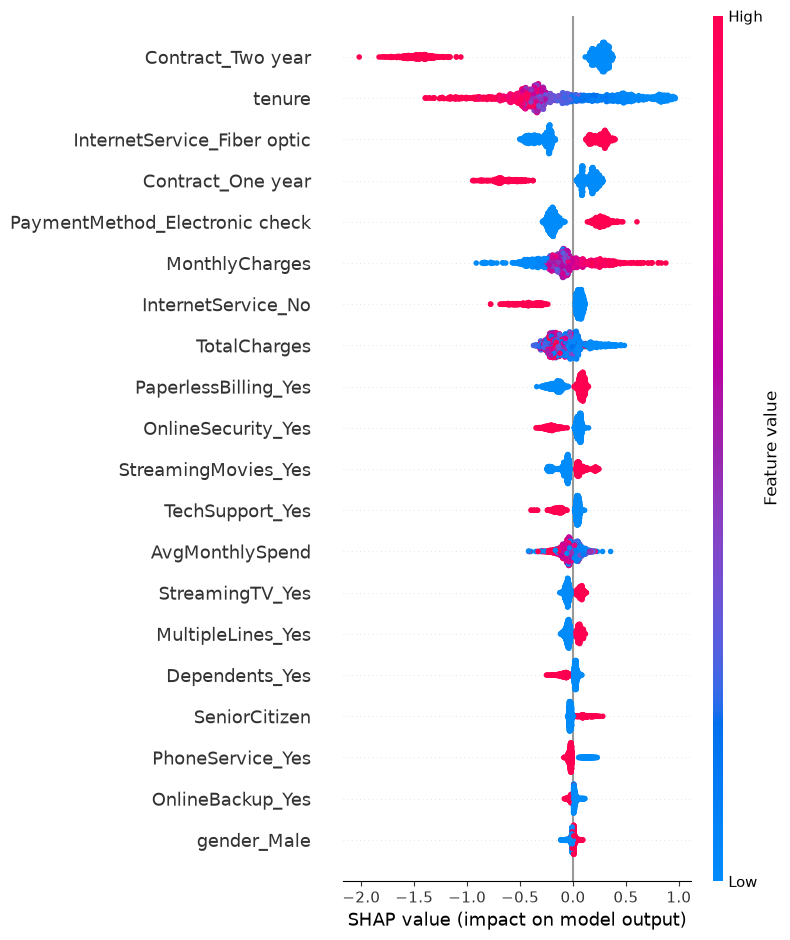

In [3]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

Actual churn: 0
Predicted probability: 0.07255271


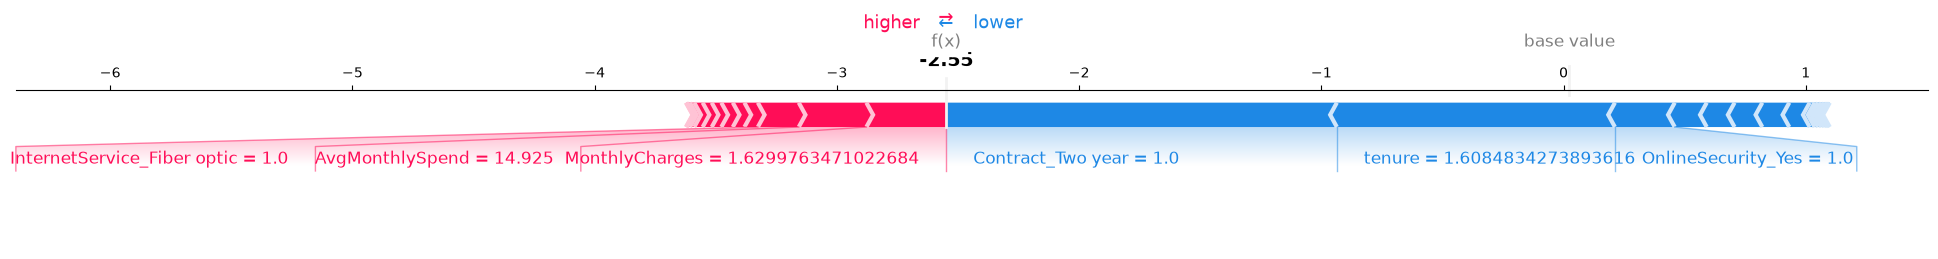

In [5]:
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
idx = 0  # first test customer

print("Actual churn:", y_test.iloc[idx])
print("Predicted probability:", final_model.predict_proba(X_test.iloc[[idx]])[0][1])

shap.force_plot(explainer.expected_value, shap_values[idx], X_test.iloc[idx], matplotlib=True, show=False)
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
np.save('../models/shap_values_test.npy', shap_values)
print("SHAP values saved")

SHAP values saved
